# Airline Sentiment — Model Comparison & Evaluation

**Goal:** Compare Naive Bayes and XGBoost against the Logistic Regression baseline on the
same TF-IDF features, then pick a final model.

Sections:
1. Rebuild data pipeline (load, clean, split, TF-IDF)
2. Logistic Regression recap
3. Naive Bayes
4. XGBoost
5. Model comparison table
6. Most predictive words per class
7. Key takeaways

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)
RANDOM_STATE = 42

## 1. Rebuild Data Pipeline

Same steps as notebook 02, repeated so this notebook can run independently.

In [2]:
df = pd.read_csv('archive/Tweets.csv')

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'&\w+;', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

df['text_clean'] = df['text'].apply(clean_tweet)
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)

X = df['text_clean']
y = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

vectorizer = TfidfVectorizer(max_features=5000, min_df=3, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Train:', X_train_tfidf.shape, ' Test:', X_test_tfidf.shape)

Train: (11712, 5000)  Test: (2928, 5000)


## 2. Logistic Regression Recap

Re-train here so all three models and their metrics live in one notebook for easy comparison.

In [3]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_tfidf, y_train)
log_reg_pred = log_reg.predict(X_test_tfidf)

print('Logistic Regression macro F1:', round(f1_score(y_test, log_reg_pred, average='macro'), 3))

Logistic Regression macro F1: 0.704


## 3. Naive Bayes

Multinomial Naive Bayes is a classic, fast baseline for text classification, built on the
(admittedly naive) assumption that words are independent given the class. It doesn't support
`class_weight`, so imbalance is handled differently here -- worth noting when comparing results.

In [4]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

print(classification_report(y_test, nb_pred))
print('Naive Bayes macro F1:', round(f1_score(y_test, nb_pred, average='macro'), 3))

              precision    recall  f1-score   support

    negative       0.72      0.98      0.83      1835
     neutral       0.67      0.24      0.36       620
    positive       0.84      0.40      0.54       473

    accuracy                           0.73      2928
   macro avg       0.75      0.54      0.58      2928
weighted avg       0.73      0.73      0.68      2928

Naive Bayes macro F1: 0.577


## 4. XGBoost

XGBoost needs numeric class labels rather than strings, so we encode the target first.
TF-IDF matrices are sparse; XGBoost handles sparse input natively, no conversion needed.

In [5]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print('Class mapping:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Class mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [6]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train_tfidf, y_train_enc)
xgb_pred_enc = xgb_model.predict(X_test_tfidf)
xgb_pred = label_encoder.inverse_transform(xgb_pred_enc)

print(classification_report(y_test, xgb_pred))
print('XGBoost macro F1:', round(f1_score(y_test, xgb_pred, average='macro'), 3))

              precision    recall  f1-score   support

    negative       0.75      0.94      0.83      1835
     neutral       0.64      0.26      0.37       620
    positive       0.74      0.58      0.65       473

    accuracy                           0.74      2928
   macro avg       0.71      0.59      0.62      2928
weighted avg       0.72      0.74      0.70      2928

XGBoost macro F1: 0.616


## 5. Model Comparison Table

In [7]:
from sklearn.metrics import accuracy_score

comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Macro F1': f1_score(y_test, log_reg_pred, average='macro'),
     'Accuracy': accuracy_score(y_test, log_reg_pred)},
    {'Model': 'Naive Bayes', 'Macro F1': f1_score(y_test, nb_pred, average='macro'),
     'Accuracy': accuracy_score(y_test, nb_pred)},
    {'Model': 'XGBoost', 'Macro F1': f1_score(y_test, xgb_pred, average='macro'),
     'Accuracy': accuracy_score(y_test, xgb_pred)},
]).set_index('Model').round(3)

comparison

,Macro F1,Accuracy
Model,,
Logistic Regression,0.704,0.750
Naive Bayes,0.577,0.729
XGBoost,0.616,0.737


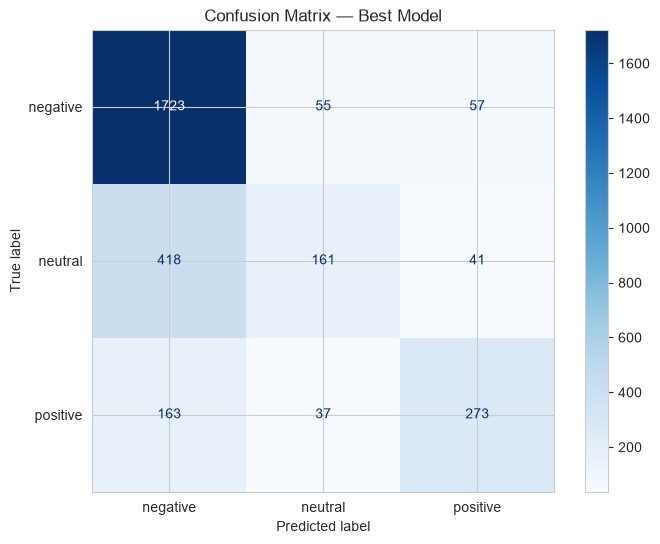

In [8]:
# Confusion matrix for whichever model performed best -- update variable name based on the table above
best_pred = xgb_pred  # change to log_reg_pred or nb_pred if a different model wins

cm = confusion_matrix(y_test, best_pred, labels=['negative', 'neutral', 'positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Best Model')
plt.show()

## 6. Most Predictive Words Per Class

Using the Logistic Regression coefficients (most directly interpretable of the three models):
which words push a prediction toward each sentiment class?

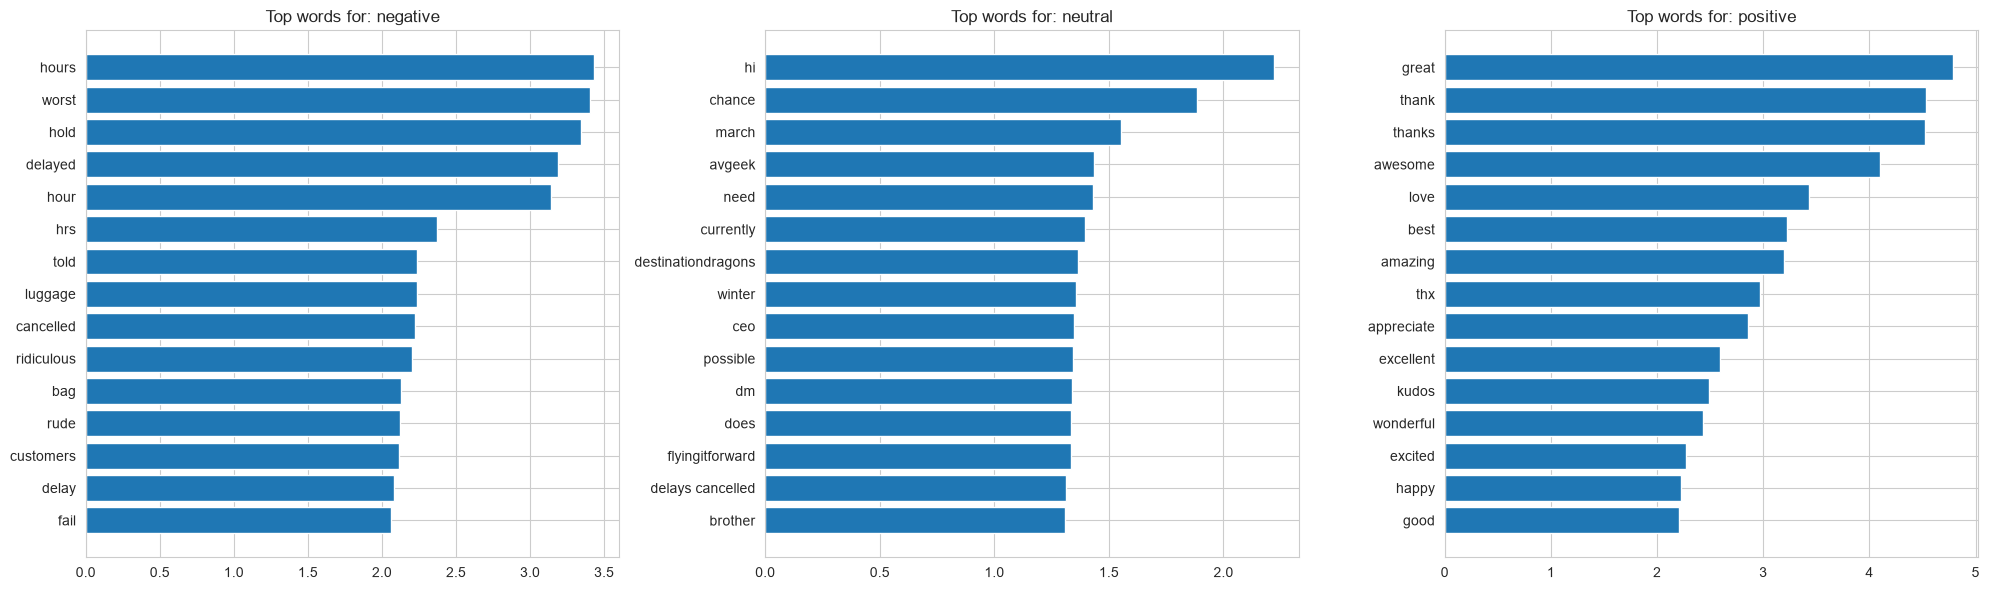

In [9]:
feature_names = np.array(vectorizer.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, class_label in zip(axes, log_reg.classes_):
    class_idx = list(log_reg.classes_).index(class_label)
    coefs = log_reg.coef_[class_idx]
    top_idx = np.argsort(coefs)[-15:]

    ax.barh(feature_names[top_idx], coefs[top_idx])
    ax.set_title(f'Top words for: {class_label}')

plt.tight_layout()
plt.show()